In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np

In [2]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()
 
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [3]:
def set_seed(seed):
    """Makes the run reproducible AND ensures each seed actually differs."""
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
 

In [4]:

def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total  # returns the number, doesn't just print

# Training Data

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:

SEEDS = [0, 42, 123]   # 3 seeds — drop to [0, 42] if time-constrained
 
for seed in SEEDS:
    print(f"\n=== Training seed {seed} ===")
    set_seed(seed)
 
    train_loader = DataLoader(train_data, batch_size=64, shuffle=True)  # reshuffled per seed
    model = TinyNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
 
    for epoch in range(5):
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")
 
    baseline_acc = evaluate(model, test_loader)
    print(f"  Seed {seed} baseline accuracy: {baseline_acc:.2f}%")
 
    torch.save(model.state_dict(), f'tinynet_fashion_seed{seed}.pth')
    print(f"  Saved: tinynet_fashion_seed{seed}.pth")


=== Training seed 0 ===
  Epoch 1 | Loss: 0.5217
  Epoch 2 | Loss: 0.3434
  Epoch 3 | Loss: 0.2980
  Epoch 4 | Loss: 0.2688
  Epoch 5 | Loss: 0.2507
  Seed 0 baseline accuracy: 89.62%
  Saved: tinynet_fashion_seed0.pth

=== Training seed 42 ===
  Epoch 1 | Loss: 0.5262
  Epoch 2 | Loss: 0.3487
  Epoch 3 | Loss: 0.3050
  Epoch 4 | Loss: 0.2760
  Epoch 5 | Loss: 0.2578
  Seed 42 baseline accuracy: 89.13%
  Saved: tinynet_fashion_seed42.pth

=== Training seed 123 ===
  Epoch 1 | Loss: 0.5196
  Epoch 2 | Loss: 0.3525
  Epoch 3 | Loss: 0.3089
  Epoch 4 | Loss: 0.2812
  Epoch 5 | Loss: 0.2589
  Seed 123 baseline accuracy: 89.32%
  Saved: tinynet_fashion_seed123.pth


# Sensitivity Sweep for sensitivy gap and layers analysis

In [6]:

SEEDS = [0, 42, 123]  

In [7]:

def load_fresh_model(seed):
    model = TinyNet()
    model.load_state_dict(torch.load(f'tinynet_fashion_seed{seed}.pth'))
    model.eval()
    return model
 
def prune_single_layer(model, layer_name, amount):
    layer = getattr(model, layer_name)
    prune.l1_unstructured(layer, name='weight', amount=amount)
    return model
 
# Sweep range — matches your original FashionMNIST full sweep checkpoints
#CHECKPOINTS = [0, 10, 20, 30, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
#CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
#CHECKPOINTS =[20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50,60, 65, 70,75,80]
CHECKPOINTS_FINE = list(range(20, 81))
LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']
 
results = {}  # results[seed][sparsity] = gap
per_layer_results = {}
for seed in SEEDS:
    print(f"\n=== Sensitivity sweep, seed {seed} ===")
    baseline_model = load_fresh_model(seed)
    baseline_acc = evaluate(baseline_model, test_loader)
 
    seed_gaps = {}
    per_layer_results[seed] = {} 
    for pct in CHECKPOINTS_FINE:
        amount = pct / 100
        layer_drops = {}
        for layer_name in LAYERS:
            m = load_fresh_model(seed)          # fresh reload — no carried-forward damage
            m = prune_single_layer(m, layer_name, amount)
            acc = evaluate(m, test_loader)
            drop = baseline_acc - acc
            layer_drops[layer_name] = drop
        per_layer_results[seed][pct] = layer_drops
        gap = max(layer_drops.values()) - min(layer_drops.values())
        seed_gaps[pct] = gap
        print(f"  {pct}% sparsity | gap = {gap:.2f}pp | drops = {layer_drops}")
 
    results[seed] = seed_gaps


=== Sensitivity sweep, seed 0 ===
  20% sparsity | gap = 0.50pp | drops = {'conv1': 0.3400000000000034, 'conv2': 0.10999999999999943, 'fc1': 0.010000000000005116, 'fc2': -0.1599999999999966}
  21% sparsity | gap = 0.33pp | drops = {'conv1': 0.3100000000000023, 'conv2': 0.07000000000000739, 'fc1': -0.01999999999999602, 'fc2': -0.009999999999990905}
  22% sparsity | gap = 0.42pp | drops = {'conv1': 0.3400000000000034, 'conv2': 0.060000000000002274, 'fc1': -0.03999999999999204, 'fc2': -0.0799999999999983}
  23% sparsity | gap = 0.44pp | drops = {'conv1': 0.38000000000000966, 'conv2': 0.060000000000002274, 'fc1': -0.060000000000002274, 'fc2': 0.020000000000010232}
  24% sparsity | gap = 0.46pp | drops = {'conv1': 0.38000000000000966, 'conv2': 0.07000000000000739, 'fc1': -0.0799999999999983, 'fc2': 0.0}
  25% sparsity | gap = 0.44pp | drops = {'conv1': 0.3400000000000034, 'conv2': 0.030000000000001137, 'fc1': -0.09999999999999432, 'fc2': -0.030000000000001137}
  26% sparsity | gap = 0.90pp

In [8]:
import json

with open('fashion_gap_20_80.json', 'w') as f:
    json.dump({'results': results, 'per_layer_results': per_layer_results}, f)

print("Saved.")

Saved.


In [ ]:
with open('fashion_gap_20_80.json', 'r') as f:
    check = json.load(f)

print(check['results'].keys())          # should show your seed values
print(check['per_layer_results']['0']['70'])   # should show the conv1/conv2/fc1/fc2 dict at 70%

dict_keys(['0', '42', '123'])
{'conv1': 10.950000000000003, 'conv2': 7.88000000000001, 'fc1': 0.7400000000000091, 'fc2': 7.920000000000002}


In [9]:

def prune_uniform(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1,   name='weight', amount=amount)
    prune.l1_unstructured(model.fc2,   name='weight', amount=amount)
    return model

uniform_results = {}

for seed in SEEDS:
    print(f"\n=== Uniform pruning sweep, seed {seed} ===")
    seed_accs = {}
    for pct in CHECKPOINTS_FINE:
        amount = pct / 100
        m = load_fresh_model(seed)
        m = prune_uniform(m, amount)
        acc = evaluate(m, test_loader)
        seed_accs[pct] = acc
        print(f"  {pct}% sparsity | accuracy = {acc:.2f}%")
    uniform_results[seed] = seed_accs

print(f"\n\n=== SUMMARY: FashionMNIST accuracy under uniform pruning, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
for pct in CHECKPOINTS_FINE:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{uniform_results[seed][pct]:>12.2f}", end="")
    print()


=== Uniform pruning sweep, seed 0 ===
  20% sparsity | accuracy = 89.24%
  21% sparsity | accuracy = 89.28%
  22% sparsity | accuracy = 89.38%
  23% sparsity | accuracy = 89.31%
  24% sparsity | accuracy = 89.21%
  25% sparsity | accuracy = 89.03%
  26% sparsity | accuracy = 88.21%
  27% sparsity | accuracy = 88.03%
  28% sparsity | accuracy = 88.21%
  29% sparsity | accuracy = 88.15%
  30% sparsity | accuracy = 88.46%
  31% sparsity | accuracy = 88.63%
  32% sparsity | accuracy = 88.57%
  33% sparsity | accuracy = 88.32%
  34% sparsity | accuracy = 87.93%
  35% sparsity | accuracy = 88.37%
  36% sparsity | accuracy = 86.24%
  37% sparsity | accuracy = 86.41%
  38% sparsity | accuracy = 86.95%
  39% sparsity | accuracy = 87.62%
  40% sparsity | accuracy = 87.62%
  41% sparsity | accuracy = 87.56%
  42% sparsity | accuracy = 87.37%
  43% sparsity | accuracy = 86.88%
  44% sparsity | accuracy = 87.50%
  45% sparsity | accuracy = 86.70%
  46% sparsity | accuracy = 86.59%
  47% sparsity |

In [10]:
print("\n\n=== SUMMARY: gap by sparsity, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
 
for pct in CHECKPOINTS_FINE:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{results[seed][pct]:>12.2f}", end="")
    print()
 
# Save results for later plotting / the reading log
import json
with open('fashionmnist_multiseed_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved: fashionmnist_multiseed_results.json")
 



=== SUMMARY: gap by sparsity, across seeds ===
  Sparsity       seed0      seed42     seed123
       20%        0.50        0.78        1.57
       21%        0.33        1.00        1.59
       22%        0.42        0.84        0.89
       23%        0.44        0.88        0.96
       24%        0.46        0.88        1.23
       25%        0.44        1.06        1.37
       26%        0.90        2.06        1.52
       27%        0.89        2.18        1.47
       28%        0.90        1.70        1.49
       29%        1.16        1.58        1.82
       30%        0.85        1.79        1.74
       31%        0.91        2.21        1.19
       32%        0.96        2.70        1.22
       33%        0.99        3.02        1.33
       34%        1.00        2.78        1.88
       35%        0.92        2.88        1.84
       36%        2.20        2.48        1.35
       37%        2.30        2.81        1.95
       38%        2.26        2.33        1.98
       39% 

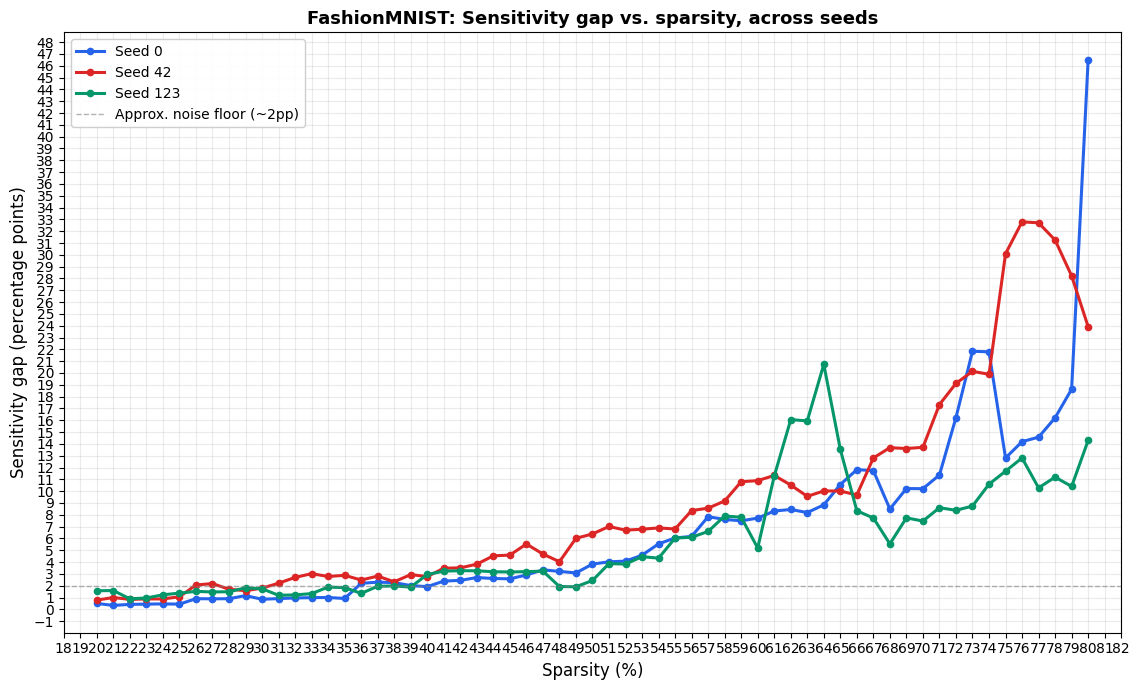

Saved: 'FashionMNIST_gap_multiseed.png


In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator 
fig, ax = plt.subplots(figsize=(11.5, 7))
 
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}
 
for seed in SEEDS:
    gaps = [results[seed][pct] for pct in CHECKPOINTS_FINE]
    ax.plot(CHECKPOINTS_FINE, gaps, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.axhline(2, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Approx. noise floor (~2pp)')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Sensitivity gap (percentage points)', fontsize=12)
ax.set_title('FashionMNIST: Sensitivity gap vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS_FINE) - 2, max(CHECKPOINTS_FINE) + 2)
ax.xaxis.set_major_locator(MultipleLocator(1))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(1)) 
plt.tight_layout()
plt.savefig('FashionMNIST_gap_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: 'FashionMNIST_gap_multiseed.png")

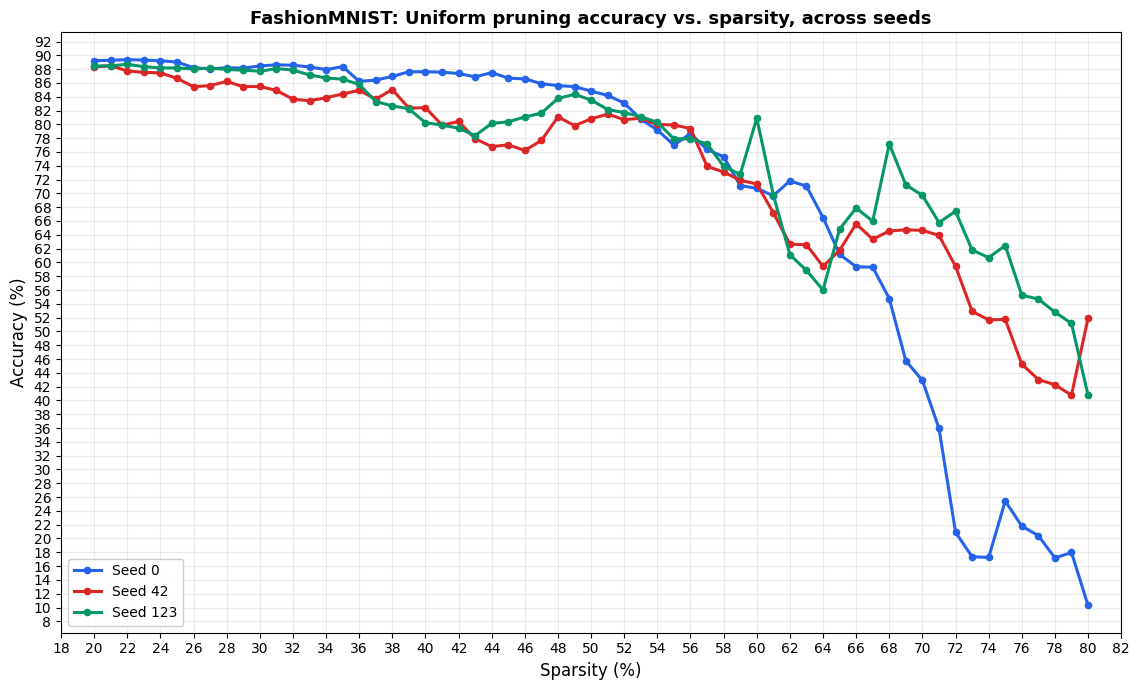

Saved: 'FashionMNIST_uniform_accuracy_multiseed.png


In [17]:
# ============================================================
# GRAPH 2 — Accuracy vs sparsity (uniform pruning), across seeds
# Uses `uniform_results` (from your uniform pruning sweep cell)
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 7))
 
for seed in SEEDS:
    accs = [uniform_results[seed][pct] for pct in CHECKPOINTS_FINE]
    ax.plot(CHECKPOINTS_FINE, accs, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('FashionMNIST: Uniform pruning accuracy vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS_FINE) - 2, max(CHECKPOINTS_FINE) + 2)
ax.xaxis.set_major_locator(MultipleLocator(2))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(2)) 
plt.tight_layout()
plt.savefig('FashionMNIST_uniform_accuracy_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: 'FashionMNIST_uniform_accuracy_multiseed.png")


Seed 0 — GAP change point
  Change point at sparsity ≈ 50%

Seed 0 — ACCURACY change point
  Change point at sparsity ≈ 71%
  --> Seed 0 lead time: 21pp


Seed 42 — GAP change point
  Change point at sparsity ≈ 71%

Seed 42 — ACCURACY change point
  Change point at sparsity ≈ 71%
  --> Seed 42 lead time: 0pp


Seed 123 — GAP change point
  Change point at sparsity ≈ 50%

Seed 123 — ACCURACY change point
  Change point at sparsity ≈ 71%
  --> Seed 123 lead time: 21pp



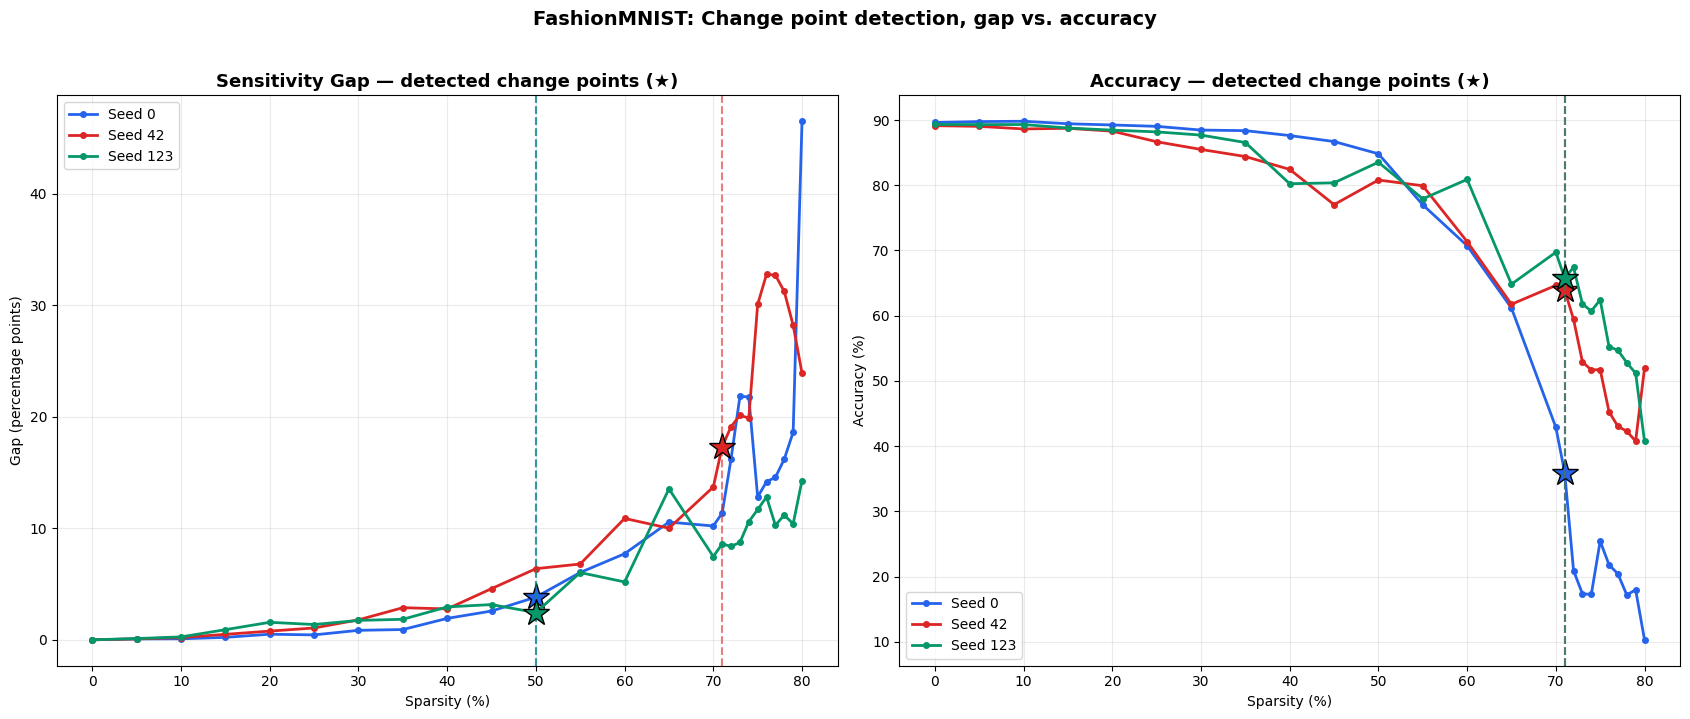


=== SUMMARY: lead times from change point detection ===
Seed 0: 21pp lead
Seed 42: 0pp lead
Seed 123: 21pp lead


In [17]:
# ============================================================
# CHANGE POINT DETECTION + GRAPH
# ============================================================

import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

def find_change_point(sparsity_values, signal_values, label=""):
    signal = np.array(signal_values)
    algo = rpt.Pelt(model="rbf").fit(signal)
    change_points = algo.predict(pen=3)
    real_points = [cp for cp in change_points if cp < len(signal)]

    print(f"\n{label}")
    if not real_points:
        print("  No significant change point detected")
        return None

    for cp_idx in real_points:
        print(f"  Change point at sparsity ≈ {sparsity_values[cp_idx]}%")

    return sparsity_values[real_points[0]]  # first detected change point


CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
ax_gap, ax_acc = axes

lead_times = {}

for seed in SEEDS:
    gap_values = [results[seed][pct] for pct in CHECKPOINTS]
    acc_values = [uniform_results[seed][pct] for pct in CHECKPOINTS]

    gap_cp = find_change_point(CHECKPOINTS, gap_values, label=f"Seed {seed} — GAP change point")
    acc_cp = find_change_point(CHECKPOINTS, acc_values, label=f"Seed {seed} — ACCURACY change point")

    if gap_cp is not None and acc_cp is not None:
        lead = acc_cp - gap_cp
        lead_times[seed] = lead
        print(f"  --> Seed {seed} lead time: {lead}pp\n")

    color = colors[seed]

    # Plot gap curve + mark its change point
    ax_gap.plot(CHECKPOINTS, gap_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    if gap_cp is not None:
        ax_gap.axvline(gap_cp, color=color, linestyle='--', alpha=0.6)
        ax_gap.plot(gap_cp, gap_values[CHECKPOINTS.index(gap_cp)], '*', color=color, markersize=20, markeredgecolor='black')

    # Plot accuracy curve + mark its change point
    ax_acc.plot(CHECKPOINTS, acc_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    if acc_cp is not None:
        ax_acc.axvline(acc_cp, color=color, linestyle='--', alpha=0.6)
        ax_acc.plot(acc_cp, acc_values[CHECKPOINTS.index(acc_cp)], '*', color=color, markersize=20, markeredgecolor='black')

ax_gap.set_title('Sensitivity Gap — detected change points (★)', fontsize=13, fontweight='bold')
ax_gap.set_xlabel('Sparsity (%)')
ax_gap.set_ylabel('Gap (percentage points)')
ax_gap.legend()
ax_gap.grid(True, alpha=0.25)

ax_acc.set_title('Accuracy — detected change points (★)', fontsize=13, fontweight='bold')
ax_acc.set_xlabel('Sparsity (%)')
ax_acc.set_ylabel('Accuracy (%)')
ax_acc.legend()
ax_acc.grid(True, alpha=0.25)

plt.suptitle('FashionMNIST: Change point detection, gap vs. accuracy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fashionmnist_changepoint.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=== SUMMARY: lead times from change point detection ===")
for seed, lead in lead_times.items():
    print(f"Seed {seed}: {lead}pp lead")

In [13]:
import json

with open('fashion_gap_20_80.json', 'r') as f:
    saved = json.load(f)

per_layer = saved['per_layer_results']  # keys are strings (JSON does this) — seed and pct both

# Count how often each layer is the max-drop (most sensitive) layer, per seed
layer_win_counts = {}

for seed_str, checkpoints in per_layer.items():
    layer_win_counts[seed_str] = {'conv1': 0, 'conv2': 0, 'fc1': 0, 'fc2': 0}
    for pct_str, drops in checkpoints.items():
        max_layer = max(drops, key=drops.get)
        layer_win_counts[seed_str][max_layer] += 1

print("=== How often each layer is the most-sensitive one, out of 21 checkpoints ===")
for seed_str, counts in layer_win_counts.items():
    print(f"Seed {seed_str}: {counts}")

print("\n=== Dominant layer at every single checkpoint (to spot flips) ===")
for seed_str, checkpoints in per_layer.items():
    print(f"\nSeed {seed_str}:")
    for pct_str in sorted(checkpoints, key=lambda x: int(x)):
        drops = checkpoints[pct_str]
        max_layer = max(drops, key=drops.get)
        print(f"  {pct_str}% -> {max_layer} (drop={drops[max_layer]:.2f})")

=== How often each layer is the most-sensitive one, out of 21 checkpoints ===
Seed 0: {'conv1': 59, 'conv2': 2, 'fc1': 0, 'fc2': 0}
Seed 42: {'conv1': 24, 'conv2': 0, 'fc1': 0, 'fc2': 37}
Seed 123: {'conv1': 34, 'conv2': 10, 'fc1': 0, 'fc2': 17}

=== Dominant layer at every single checkpoint (to spot flips) ===

Seed 0:
  20% -> conv1 (drop=0.34)
  21% -> conv1 (drop=0.31)
  22% -> conv1 (drop=0.34)
  23% -> conv1 (drop=0.38)
  24% -> conv1 (drop=0.38)
  25% -> conv1 (drop=0.34)
  26% -> conv1 (drop=0.84)
  27% -> conv1 (drop=0.84)
  28% -> conv1 (drop=0.85)
  29% -> conv1 (drop=1.08)
  30% -> conv1 (drop=0.77)
  31% -> conv1 (drop=0.77)
  32% -> conv1 (drop=0.83)
  33% -> conv1 (drop=0.91)
  34% -> conv1 (drop=0.91)
  35% -> conv1 (drop=0.85)
  36% -> conv1 (drop=2.14)
  37% -> conv1 (drop=2.09)
  38% -> conv1 (drop=2.09)
  39% -> conv1 (drop=1.82)
  40% -> conv1 (drop=1.86)
  41% -> conv1 (drop=2.30)
  42% -> conv1 (drop=2.30)
  43% -> conv1 (drop=2.60)
  44% -> conv1 (drop=2.56)
  4

NameError: name 'SEEDS' is not defined

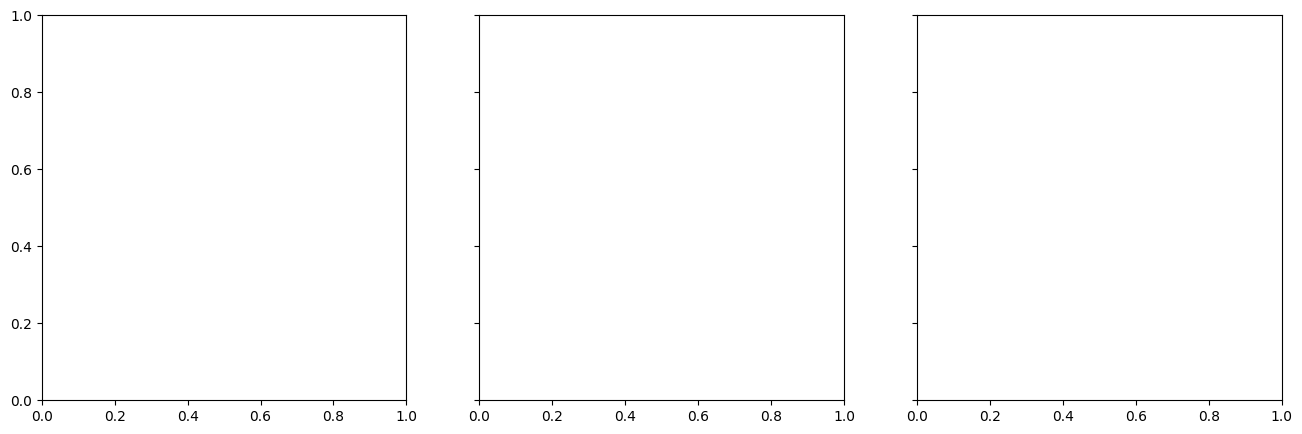

In [ ]:
import json
import matplotlib.pyplot as plt

with open('fashion_gap_20_80.json', 'r') as f:
    saved = json.load(f)

per_layer = saved['per_layer_results']  # seed -> pct -> {layer: drop}, all keys are strings after JSON reload

layer_colors = {'conv1': '#1D4ED8', 'conv2': '#059669', 'fc1': '#D97706', 'fc2': '#7C3AED'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, seed in zip(axes, SEEDS):
    seed_str = str(seed)
    checkpoints = sorted(per_layer[seed_str].keys(), key=lambda x: int(x))
    sparsities = [int(pct) for pct in checkpoints]

    for layer_name, color in layer_colors.items():
        drops = [per_layer[seed_str][pct][layer_name] for pct in checkpoints]
        ax.plot(sparsities, drops, '-o', color=color, linewidth=2, markersize=4, label=layer_name)

    ax.set_title(f'Seed {seed}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sparsity (%)')
    ax.grid(True, alpha=0.25)
ax.yaxis.set_major_locator(MultipleLocator(1))
axes[0].set_ylabel('Accuracy drop from baseline (pp)')
axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle('FashionMNIST: per-layer sensitivity, 20-80% sparsity, across seeds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fashion_layer_analysis_20_80.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fashion_layer_analysis_20_80.png")